In [1]:
import sys

project_path = r'D:\programming\specializaion track\Data Engineering\Big Data\Python\ecommerce-data-pipeline'
sys.path.insert(0, project_path)
import src.ingestion

In [2]:
import importlib
import src.cleaning
import numpy as np
import pandas as pd

importlib.reload(src.cleaning)

<module 'src.cleaning' from 'D:\\programming\\specializaion track\\Data Engineering\\Big Data\\Python\\ecommerce-data-pipeline\\src\\cleaning.py'>

In [3]:
from src.ingestion import load_data
from src.cleaning import clean_data
from src.Transformation import prepare_sales_data
from src.analysis import *

df = load_data('../Data/raw/online_retail_II.csv')

df = clean_data(df)

df = prepare_sales_data(df)

customer_summary = create_customer_summary(df)
product_summary = create_product_summary(df)
country_summary = create_Country_summary(df)
monthly_summary = create_monthly_summary(df)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Year,Day,Hour,TransactionType
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,12,2009,1,7,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,12,2009,1,7,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,12,2009,1,7,Sale
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5,12,2009,1,7,Sale
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,30.6,12,2009,1,7,Sale


In [20]:
customer_summary

,Customer ID,Revenue,Quantity
0,12346,-51.74,53
1,12347,3578.67,1567
2,12348,478.2,114
3,12349,3947.94,1057
4,12350,314.0,173
...,...,...,...
5782,18283,2664.9,1679
5783,18284,270.9,142
5784,18285,223.0,65
5785,18286,1119.79,472


In [21]:
product_summary

,StockCode,Revenue,Quantity
0,10002,1743.79,1924
1,10002R,20.57,4
2,10080,62.99,145
3,10109,1.68,4
4,10120,54.54,244
...,...,...,...
4871,gift_0001_40,166.09,5
4872,gift_0001_50,253.59,6
4873,gift_0001_70,59.57,1
4874,gift_0001_80,0.0,0


d:\programming\specializaion track\Data Engineering\Big Data\Python\ecommerce-data-pipeline


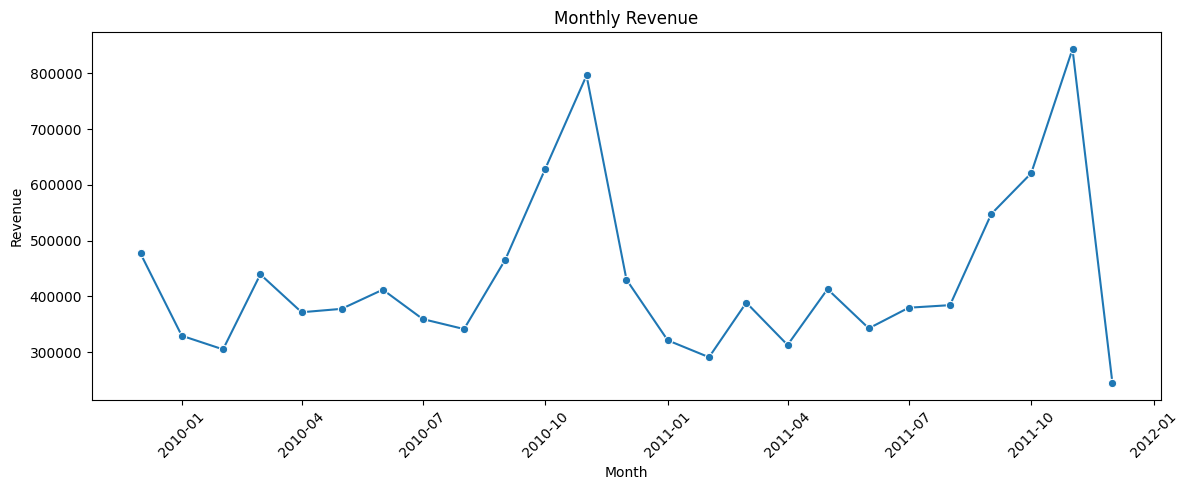

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print(os.getcwd())

monthly = pd.read_csv("Data/processed/monthly_sales.csv")

monthly["Date"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" +
    monthly["Month"].astype(str) + "-01"
)

monthly = monthly.sort_values("Date")

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="Date", y="Revenue", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("reports/monthly_revenue.png", dpi=150)
plt.show()

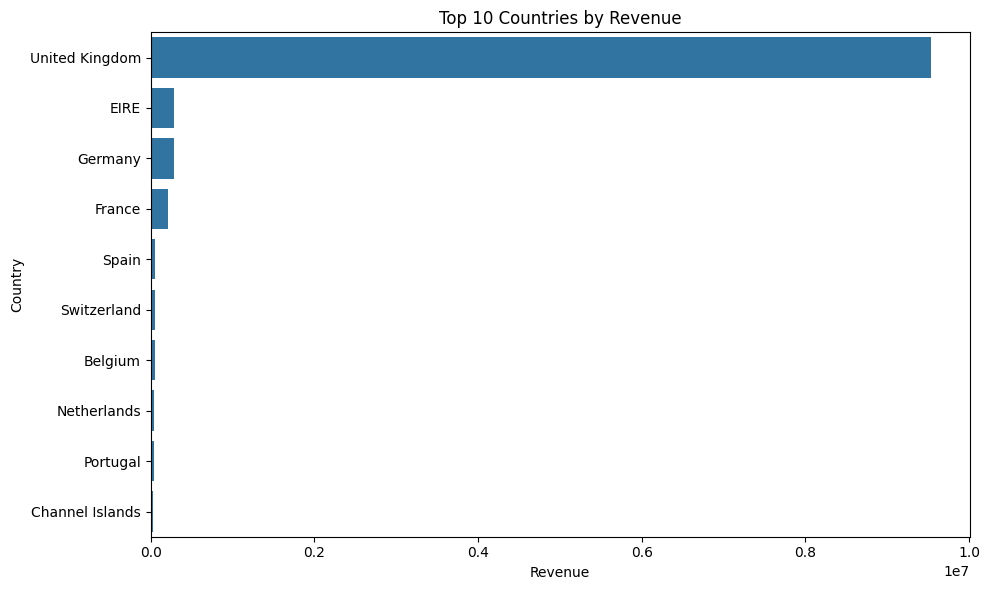

In [9]:
countries = pd.read_csv("Data/processed/country_summary.csv")

top_countries = (
    countries
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig("reports/top_countries.png", dpi=150)
plt.show()

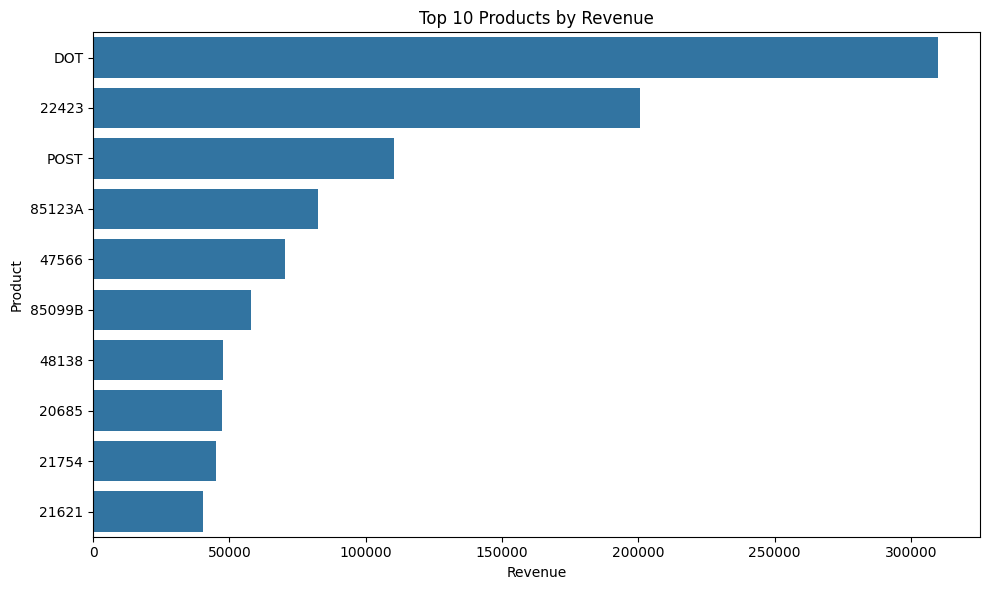

In [8]:
products = pd.read_csv("Data/processed/product_summary.csv")

top_products = (
    products
    .sort_values("Revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_products,
    x="Revenue",
    y="StockCode"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig("reports/top_products.png", dpi=150)
plt.show()

In [5]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current directory:
d:\programming\specializaion track\Data Engineering\Big Data\Python\ecommerce-data-pipeline\notebooks

Files:
['exploration.ipynb']


In [6]:
import os

os.chdir("..")

print(os.getcwd())

d:\programming\specializaion track\Data Engineering\Big Data\Python\ecommerce-data-pipeline


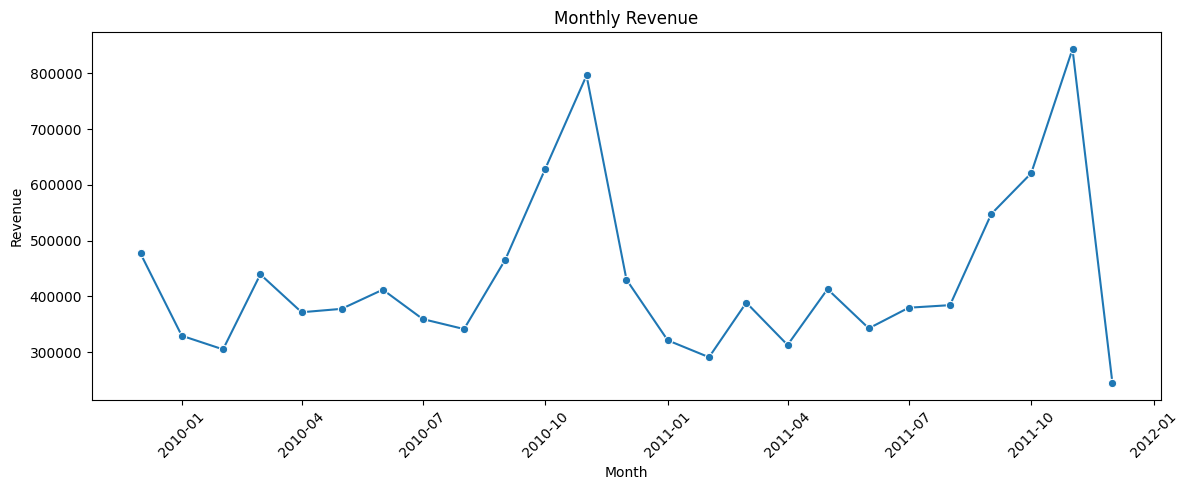

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

monthly = pd.read_csv("Data/processed/monthly_sales.csv")

monthly["Date"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" +
    monthly["Month"].astype(str) + "-01"
)

monthly = monthly.sort_values("Date")

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly,
    x="Date",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()